This project implements a content-based movie recommendation system using Machine Learning techniques. The system recommends movies based on genre similarity using TF-IDF and cosine similarity.

In [4]:
import pandas as pd

ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
movies.head()


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
df = pd.merge(ratings, movies, on='movieId')
df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [7]:
movies_matrix = df.pivot_table(
    index = 'title',
    columns='userId',
    values='rating'
)

movies_matrix.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
'Hellboy': The Seeds of Creation (2004),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
'Round Midnight (1986),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
'Salem's Lot (2004),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
'Til There Was You (1997),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
movies_matrix_filled = movies_matrix.fillna(0)


In [9]:
movies_matrix_filled.head()


userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
'Hellboy': The Seeds of Creation (2004),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Round Midnight (1986),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Salem's Lot (2004),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Til There Was You (1997),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(movies_matrix_filled)


In [11]:
similarity.shape


(9719, 9719)

In [12]:
def recommend(movie_name, top_n=5):

    if movie_name not in movies_matrix.index:
        return "Movie not found"

    movie_index = movies_matrix.index.get_loc(movie_name)

    similarity_scores = list(enumerate(similarity[movie_index]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommended_movies = []

    for i in similarity_scores[1:top_n+1]:
        recommended_movies.append(movies_matrix.index[i[0]])

    return recommended_movies


In [13]:
recommend("Toy Story (1995)")

['Toy Story 2 (1999)',
 'Jurassic Park (1993)',
 'Independence Day (a.k.a. ID4) (1996)',
 'Star Wars: Episode IV - A New Hope (1977)',
 'Forrest Gump (1994)']

In [14]:
ratings_count = df.groupby('title')['rating'].count()

ratings_count.describe()



count    9719.000000
mean       10.375141
std        22.406220
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: rating, dtype: float64

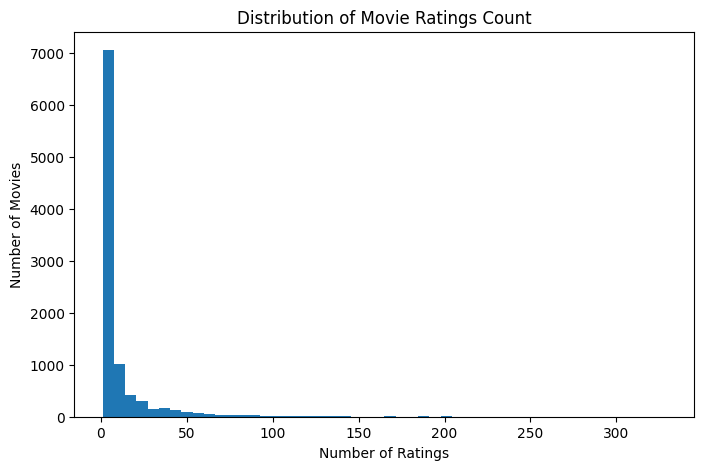

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(ratings_count, bins=50)
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movie Ratings Count")
plt.show()


In [17]:
ratings_count.quantile([0.5, 0.6, 0.7, 0.8, 0.9])


0.5     3.0
0.6     4.0
0.7     7.0
0.8    12.0
0.9    27.0
Name: rating, dtype: float64

In [18]:
popular_movies = ratings_count[ratings_count >= 20].index

filtered_df = df[df['title'].isin(popular_movies)]

len(popular_movies)


1297

In [19]:
movies_matrix = filtered_df.pivot_table(
    index='title',
    columns='userId',
    values='rating'
)

movies_matrix_filled = movies_matrix.fillna(0)

from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(movies_matrix_filled)

similarity.shape


(1297, 1297)

In [20]:
def recommend(movie_name, top_n=5):

    if movie_name not in movies_matrix.index:
        return "Movie not found"

    movie_index = movies_matrix.index.get_loc(movie_name)

    similarity_scores = list(enumerate(similarity[movie_index]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommended_movies = []

    for i in similarity_scores[1:top_n+1]:
        recommended_movies.append(movies_matrix.index[i[0]])

    return recommended_movies


In [21]:
recommend("Toy Story (1995)")


['Toy Story 2 (1999)',
 'Jurassic Park (1993)',
 'Independence Day (a.k.a. ID4) (1996)',
 'Star Wars: Episode IV - A New Hope (1977)',
 'Forrest Gump (1994)']

In [22]:
recommend("Round Midnight (1986)")


'Movie not found'

In [23]:
!pip install rapidfuzz


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 1.8 MB/s eta 0:00:01
   --------------------------- ------------ 1.0/1.5 MB 1.7 MB/s eta 0:00:01
   ---------------------------------- ----- 1.3/1.5 MB 1.7 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.7 MB/s  0:00:01



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\pashv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [24]:
from rapidfuzz import process


In [25]:
def search_candidates(query):
    return [title for title in movies_matrix.index
            if query.lower() in title.lower()]


In [26]:
from rapidfuzz import process, fuzz

def find_closest_movie(query, threshold=55):

    # Step 1: substring match first
    candidates = [
        title for title in movies_matrix.index
        if query.lower() in title.lower()
    ]

    if len(candidates) > 0:
        return candidates[0]

    # Step 2: fuzzy with WRatio
    match = process.extractOne(
        query,
        movies_matrix.index,
        scorer=fuzz.WRatio
    )

    if match and match[1] >= threshold:
        return match[0]

    return None



In [27]:
find_closest_movie("toy s")


'Toy Story (1995)'

In [28]:
def recommend(movie_name, top_n=5):

    matched_movie = find_closest_movie(movie_name)

    if matched_movie is None:
        return "Movie not found. Please refine search."

    movie_index = movies_matrix.index.get_loc(matched_movie)

    similarity_scores = list(enumerate(similarity[movie_index]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommended_movies = []

    for i in similarity_scores[1:top_n+1]:
        recommended_movies.append(movies_matrix.index[i[0]])

    return {
        "matched_movie": matched_movie,
        "recommendations": recommended_movies
    }


In [29]:
recommend("toy s")


{'matched_movie': 'Toy Story (1995)',
 'recommendations': ['Toy Story 2 (1999)',
  'Jurassic Park (1993)',
  'Independence Day (a.k.a. ID4) (1996)',
  'Star Wars: Episode IV - A New Hope (1977)',
  'Forrest Gump (1994)']}

In [30]:
recommend("toy stroy")

{'matched_movie': 'Toy Story (1995)',
 'recommendations': ['Toy Story 2 (1999)',
  'Jurassic Park (1993)',
  'Independence Day (a.k.a. ID4) (1996)',
  'Star Wars: Episode IV - A New Hope (1977)',
  'Forrest Gump (1994)']}

In [31]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)


In [32]:
def precision_at_k(user_id, k=5):

    # Movies user liked in test set (rating >= 4)
    user_test_movies = test_df[
        (test_df['userId'] == user_id) &
        (test_df['rating'] >= 4)
    ]['title'].tolist()

    if len(user_test_movies) == 0:
        return None

    hits = 0
    total = 0

    # Take one movie user liked from train
    user_train_movies = train_df[
        (train_df['userId'] == user_id) &
        (train_df['rating'] >= 4)
    ]['title'].tolist()

    if len(user_train_movies) == 0:
        return None

    # Use first liked movie for recommendation
    recommended = recommend(user_train_movies[0], top_n=k)

    if recommended is None:
        return None

    for movie in recommended["recommendations"]:
        if movie in user_test_movies:
            hits += 1

    total = k

    return hits / total


In [33]:
import numpy as np

scores = []

for user in test_df['userId'].unique()[:100]:
    score = precision_at_k(user, k=5)
    if score is not None:
        scores.append(score)

np.mean(scores)


np.float64(0.08)

In [34]:
def recommend_for_user(user_id, k=5):

    user_train_movies = train_df[
        (train_df['userId'] == user_id) &
        (train_df['rating'] >= 4)
    ]['title'].tolist()

    if len(user_train_movies) == 0:
        return None

    scores = {}

    for movie in user_train_movies:
        if movie not in movies_matrix.index:
            continue

        movie_index = movies_matrix.index.get_loc(movie)
        similarity_scores = list(enumerate(similarity[movie_index]))

        for idx, score in similarity_scores:
            title = movies_matrix.index[idx]

            if title not in user_train_movies:
                scores[title] = scores.get(title, 0) + score

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    return [movie for movie, _ in ranked[:k]]


In [35]:
def precision_at_k(user_id, k=5):

    user_test_movies = test_df[
        (test_df['userId'] == user_id) &
        (test_df['rating'] >= 4)
    ]['title'].tolist()

    if len(user_test_movies) == 0:
        return None

    recommended = recommend_for_user(user_id, k=k)

    if recommended is None:
        return None

    hits = 0

    for movie in recommended:
        if movie in user_test_movies:
            hits += 1

    return hits / k


In [ ]:
scores = []

for user in test_df['userId'].unique()[:100]:
    score = precision_at_k(user, k=5)
    if score is not None:
        scores.append(score)

np.mean(scores)


np.float64(0.3720000000000001)

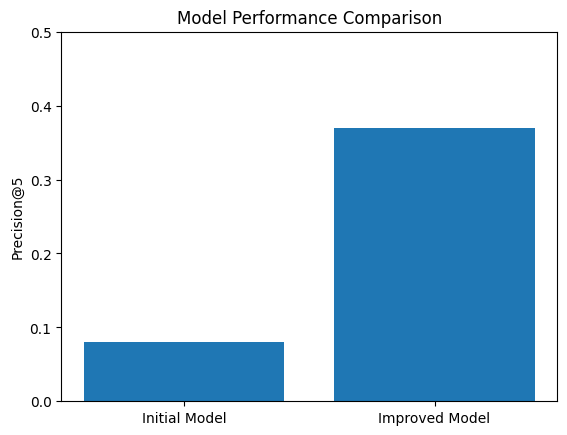

In [37]:
import matplotlib.pyplot as plt

labels = ['Initial Model', 'Improved Model']
values = [0.08, 0.37]

plt.bar(labels, values)
plt.ylabel('Precision@5')
plt.title('Model Performance Comparison')
plt.ylim(0, 0.5)
plt.show()
